In [14]:
# === Intelligent Anomaly Detection in Network Traffic Using Advanced Machine Learning Techniques ===

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

import warnings
warnings.filterwarnings("ignore")

In [15]:
# === 1. Load Data ===
df = pd.read_csv("kddcup99.csv")
df.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label
0,0,tcp,http,SF,181,5450,0,0,0,0,...,9,1.0,0.0,0.11,0.0,0.0,0.0,0.0,0.0,normal
1,0,tcp,http,SF,239,486,0,0,0,0,...,19,1.0,0.0,0.05,0.0,0.0,0.0,0.0,0.0,normal
2,0,tcp,http,SF,235,1337,0,0,0,0,...,29,1.0,0.0,0.03,0.0,0.0,0.0,0.0,0.0,normal
3,0,tcp,http,SF,219,1337,0,0,0,0,...,39,1.0,0.0,0.03,0.0,0.0,0.0,0.0,0.0,normal
4,0,tcp,http,SF,217,2032,0,0,0,0,...,49,1.0,0.0,0.02,0.0,0.0,0.0,0.0,0.0,normal


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 494020 entries, 0 to 494019
Data columns (total 42 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   duration                     494020 non-null  int64  
 1   protocol_type                494020 non-null  object 
 2   service                      494020 non-null  object 
 3   flag                         494020 non-null  object 
 4   src_bytes                    494020 non-null  int64  
 5   dst_bytes                    494020 non-null  int64  
 6   land                         494020 non-null  int64  
 7   wrong_fragment               494020 non-null  int64  
 8   urgent                       494020 non-null  int64  
 9   hot                          494020 non-null  int64  
 10  num_failed_logins            494020 non-null  int64  
 11  logged_in                    494020 non-null  int64  
 12  lnum_compromised             494020 non-null  int64  
 13 

In [17]:
df.isnull().sum()

,0
duration,0
protocol_type,0
service,0
flag,0
src_bytes,0
dst_bytes,0
land,0
wrong_fragment,0
urgent,0
hot,0


In [18]:
# === 2. Data Cleaning ===
df.columns = df.columns.str.strip()

# Encode categorical variables
categorical_cols = df.select_dtypes(include='object').columns.tolist()
categorical_cols.remove('label')
for col in categorical_cols:
    df[col] = LabelEncoder().fit_transform(df[col])

# Encode target variable: normal = 0, attack = 1
df['label'] = df['label'].apply(lambda x: 0 if x == 'normal' else 1)

# Drop duplicates
df.drop_duplicates(inplace=True)

In [19]:
# === 3. Balance the dataset with equal sampling ===
normal_df = df[df['label'] == 0]
anomaly_df = df[df['label'] == 1]

minority_size = min(len(normal_df), len(anomaly_df))
normal_sample = normal_df.sample(n=minority_size, random_state=42)
anomaly_sample = anomaly_df.sample(n=minority_size, random_state=42)

balanced_df = pd.concat([normal_sample, anomaly_sample]).sample(frac=1, random_state=42).reset_index(drop=True)

Label distribution:
 label
1    57753
0    57753
Name: count, dtype: int64


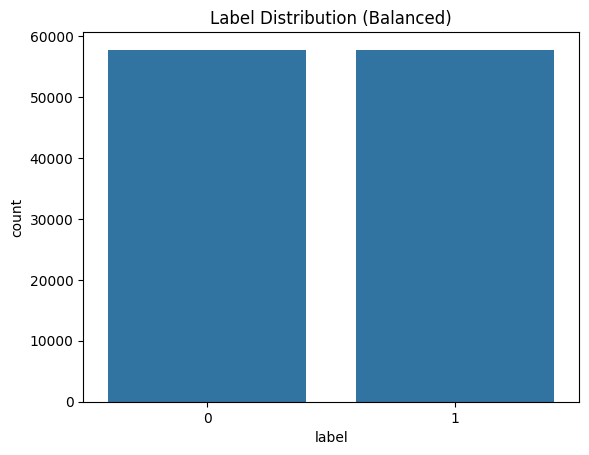

In [20]:
# === 4. Exploratory Data Analysis (EDA) ===
print("Label distribution:\n", balanced_df['label'].value_counts())
sns.countplot(x='label', data=balanced_df)
plt.title("Label Distribution (Balanced)")
plt.show()

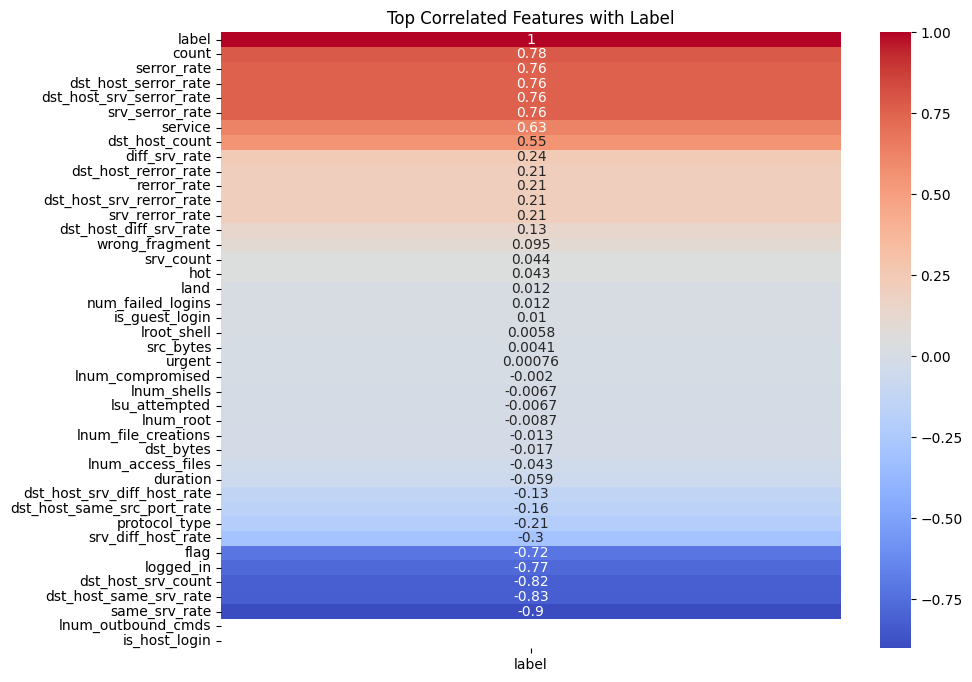

In [21]:
# Correlation Heatmap
corr = balanced_df.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr[['label']].sort_values(by='label', ascending=False), annot=True, cmap='coolwarm')
plt.title("Top Correlated Features with Label")
plt.show()

In [22]:
# === 5. Preprocessing ===
X = balanced_df.drop('label', axis=1)
y = balanced_df['label']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train/Validation/Test Split
X_temp, X_test, y_temp, y_test = train_test_split(X_scaled, y, test_size=0.2, stratify=y, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, stratify=y_temp, random_state=42)


In [23]:

# === 6. Classical ML Model Training & Evaluation ===
models = {
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVM": SVC(probability=True),
    "KNN": KNeighborsClassifier()
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    results[name] = {
        "Accuracy": accuracy_score(y_val, y_pred),
        "Precision": precision_score(y_val, y_pred),
        "Recall": recall_score(y_val, y_pred),
        "F1-Score": f1_score(y_val, y_pred),
        "ROC-AUC": roc_auc_score(y_val, y_pred)
    }
    print(f"\nClassification Report for {name}:")
    print(classification_report(y_val, y_pred))


Classification Report for Random Forest:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     11551
           1       1.00      1.00      1.00     11550

    accuracy                           1.00     23101
   macro avg       1.00      1.00      1.00     23101
weighted avg       1.00      1.00      1.00     23101


Classification Report for SVM:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     11551
           1       1.00      1.00      1.00     11550

    accuracy                           1.00     23101
   macro avg       1.00      1.00      1.00     23101
weighted avg       1.00      1.00      1.00     23101


Classification Report for KNN:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     11551
           1       1.00      1.00      1.00     11550

    accuracy                           1.00     23101
   macro avg       1.0

In [25]:
# === 7. Deep Learning Model ===
dnn_model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

dnn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history = dnn_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

# Evaluate on validation set
dnn_val_preds = (dnn_model.predict(X_val) > 0.5).astype(int)
results['Deep Learning'] = {
    "Accuracy": accuracy_score(y_val, dnn_val_preds),
    "Precision": precision_score(y_val, dnn_val_preds),
    "Recall": recall_score(y_val, dnn_val_preds),
    "F1-Score": f1_score(y_val, dnn_val_preds),
    "ROC-AUC": roc_auc_score(y_val, dnn_val_preds)
}



Epoch 1/20
1083/1083 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9672 - loss: 0.1019 - val_accuracy: 0.9957 - val_loss: 0.0169
Epoch 2/20
1083/1083 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - accuracy: 0.9957 - loss: 0.0184 - val_accuracy: 0.9960 - val_loss: 0.0145
Epoch 3/20
1083/1083 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.9964 - loss: 0.0143 - val_accuracy: 0.9963 - val_loss: 0.0137
Epoch 4/20
1083/1083 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9967 - loss: 0.0129 - val_accuracy: 0.9967 - val_loss: 0.0132
Epoch 5/20
1083/1083 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9969 - loss: 0.0100 - val_accuracy: 0.9967 - val_loss: 0.0124
Epoch 6/20
1083/1083 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9967 - loss: 0.0104 - val_accuracy: 0.9967 - val_loss: 0.0121
Epoch 7/20
1083/1083 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9973 - loss: 0.0102 - val_accuracy: 0.9964 - val_loss: 0.0136
Epoch 8/20
1083/1083 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9974 - loss: 0.0095

In [26]:
print("\nClassification Report for Deep Learning:")
print(classification_report(y_val, dnn_val_preds))


Classification Report for Deep Learning:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     11551
           1       1.00      1.00      1.00     11550

    accuracy                           1.00     23101
   macro avg       1.00      1.00      1.00     23101
weighted avg       1.00      1.00      1.00     23101



In [27]:
# Summary of all model results
results_df = pd.DataFrame(results).T
print("\nEvaluation Summary:\n", results_df)


Evaluation Summary:
                Accuracy  Precision    Recall  F1-Score   ROC-AUC
Random Forest  0.998875   0.999393  0.998355  0.998874  0.998874
SVM            0.996667   0.997485  0.995844  0.996664  0.996667
KNN            0.997403   0.997747  0.997056  0.997402  0.997403
Deep Learning  0.997013   0.996798  0.997229  0.997014  0.997013
